In [5]:
# Basic required
!pip install torch torchvision matplotlib scikit-learn opencv-python tqdm tensorboard pillow

# Recommended (fast similarity search; optional)
!pip install faiss-cpu       # or faiss-gpu if available and compatible

# If you want to use BLIP / VLM models (optional, for semantic captioning):
!pip install transformers ftfy accelerate sentence-transformers
!pip install git+https://github.com/salesforce/BLIP  # check upstream instructions
# or use huggingface "Salesforce/blip-image-captioning-base"

# For graph operations
!pip install networkx

  Cloning https://github.com/salesforce/BLIP to /tmp/pip-req-build-khypykct
  Running command git clone --filter=blob:none --quiet https://github.com/salesforce/BLIP /tmp/pip-req-build-khypykct
  Resolved https://github.com/salesforce/BLIP to commit 056a169437371659074aa2732649d5de3bffb4a8
ERROR: git+https://github.com/salesforce/BLIP does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [6]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [7]:
import os
# Check if the directory exists and what is inside it
path_to_check = "/kaggle/input/kitti-dataset/Dataset" 
if os.path.exists(path_to_check):
    print("Directory found!")
    print("Contents:", os.listdir(path_to_check)[:10]) # Show first 10 items
else:
    print("Directory NOT found. Please check the 'Data' sidebar on the right.")

Directory found!
Contents: ['poses', 'sequences']


In [12]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from transformers import (AutoImageProcessor, AutoModel, 
                          CLIPProcessor, CLIPModel, 
                          SiglipProcessor, SiglipModel)
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 1. GLOBAL CONFIGURATION
# ==========================================
class Config:
    BASE_DIR = "/kaggle/input/kitti-dataset/Dataset"
    SEQUENCES = ["00", "01", "05", "06"] 
    MODELS_TO_TEST = ["dinov2", "clip", "siglip"]
    
    MODEL_MAP = {
        "dinov2": "facebook/dinov2-base",
        "clip": "openai/clip-vit-base-patch32",
        "siglip": "google/siglip-base-patch16-224"
    }
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    UTILITY_THRESHOLD = 0.20
    ALPHA, BETA = 0.75, 0.25  # Weights for Shift and Entropy

# ==========================================
# 2. THE UNIVERSAL EXTRACTOR ENGINE
# ==========================================
class UniversalExtractor:
    def __init__(self, mode):
        self.mode = mode
        m_id = Config.MODEL_MAP[mode]
        print(f"\n>>> Loading {mode.upper()}...")
        
        if mode == "dinov2":
            self.proc = AutoImageProcessor.from_pretrained(m_id)
            self.model = AutoModel.from_pretrained(m_id).to(Config.DEVICE)
        elif mode == "clip":
            self.proc = CLIPProcessor.from_pretrained(m_id)
            self.model = CLIPModel.from_pretrained(m_id).to(Config.DEVICE)
        elif mode == "siglip":
            self.proc = SiglipProcessor.from_pretrained(m_id)
            self.model = SiglipModel.from_pretrained(m_id).to(Config.DEVICE)
        self.model.eval()

    def get_features(self, image_path):
        img = Image.open(image_path).convert("RGB")
        inputs = self.proc(images=img, return_tensors="pt").to(Config.DEVICE)
        
        with torch.no_grad():
            if self.mode == "dinov2":
                out = self.model(**inputs)
                # DINOv2 uses the first token (CLS)
                emb = out.last_hidden_state[:, 0, :]
            elif self.mode == "clip":
                # CLIP has a dedicated method for image features
                emb = self.model.get_image_features(**inputs)
            elif self.mode == "siglip":
                # SigLIP also uses get_image_features
                emb = self.model.get_image_features(**inputs)
            
            # --- CRITICAL FIX START ---
            # Ensure 'emb' is a raw torch.Tensor, not a BaseModelOutput object
            if not isinstance(emb, torch.Tensor):
                # If it's a wrapper, extract the underlying tensor
                emb = emb.pooler_output if hasattr(emb, 'pooler_output') else emb[0]
            
            # Detach and calculate Softmax for Entropy
            emb_tensor = emb.detach() 
            probs = F.softmax(emb_tensor, dim=-1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-9)).item()
            # --- CRITICAL FIX END ---
            
            return emb_tensor.cpu().numpy(), entropy
# ==========================================
# 3. AUTOMATED BENCHMARK ENGINE
# ==========================================
def run_benchmark():
    master_results = []
    
    for model_name in Config.MODELS_TO_TEST:
        extractor = UniversalExtractor(model_name)
        
        for seq in Config.SEQUENCES:
            img_dir = os.path.join(Config.BASE_DIR, "sequences", seq, "image_2")
            images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))])
            
            keyframes, last_emb, seq_log = [], None, []
            
            print(f"Processing Seq {seq} with {model_name}...")
            for i, name in enumerate(tqdm(images, leave=False)):
                emb, ent = extractor.get_features(os.path.join(img_dir, name))
                
                if i == 0:
                    is_kf, utility, shift, last_emb = True, 1.0, 1.0, emb
                else:
                    shift = 1 - cosine_similarity(emb, last_emb)[0][0]
                    norm_ent = (ent - 5.0) / 3.0 # Basic normalization for DINO/CLIP range
                    utility = (Config.ALPHA * shift) + (Config.BETA * norm_ent)
                    is_kf = utility > Config.UTILITY_THRESHOLD
                
                if is_kf:
                    keyframes.append(i)
                    last_emb = emb
                
                seq_log.append({'frame': i, 'utility': utility, 'entropy': ent, 'is_kf': is_kf})
            
            # --- Calculate Summary Metrics for this Run ---
            total_frames = len(images)
            num_kf = len(keyframes)
            compression = (1 - (num_kf / total_frames)) * 100
            avg_entropy = np.mean([x['entropy'] for x in seq_log])
            
            master_results.append({
                'Model': model_name,
                'Sequence': seq,
                'Total_Frames': total_frames,
                'Keyframes_Selected': num_kf,
                'Compression_Ratio': f"{compression:.2f}%",
                'Avg_Informativeness': f"{avg_entropy:.4f}"
            })
            
            # Save individual log for the sequence
            pd.DataFrame(seq_log).to_csv(f"raw_log_{model_name}_seq{seq}.csv", index=False)
            
    return pd.DataFrame(master_results)

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    final_table = run_benchmark()
    
    print("\n" + "="*50)
    print("MASTER COMPARISON TABLE - ARTICLE 1")
    print("="*50)
    print(final_table.to_string(index=False))
    
    # Save the crown jewel of your research
    final_table.to_csv("article1_master_benchmark.csv", index=False)
    print("\nAll results saved to 'article1_master_benchmark.csv'")


>>> Loading DINOV2...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Processing Seq 00 with dinov2...


Processing Seq 01 with dinov2...


Processing Seq 05 with dinov2...


...

Processing Seq 00 with siglip...


Processing Seq 01 with siglip...


Processing Seq 05 with siglip...


Processing Seq 06 with siglip...



MASTER COMPARISON TABLE - ARTICLE 1
 Model Sequence  Total_Frames  Keyframes_Selected Compression_Ratio Avg_Informativeness
dinov2       00          4541                 316            93.04%              5.2950
dinov2       01          1101                  27            97.55%              5.2502
dinov2       05          2761                 153            94.46%              5.3168
dinov2       06          1101                  62            94.37%              5.2133
  clip       00          4541                 147            96.76%              6.1563
  clip       01          1101                  12            98.91%              6.1466
  clip       05          2761                 102            96.31%              6.1533
  clip       06          1101                  48            95.64%              6.1557
siglip       00          4541                   9            99.80%              4.0473
siglip       01          1101                   1            99.91%              4.


>>> Initializing DINOV2...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

dinov2 - 00: 100%|██████████| 4541/4541 [02:48<00:00, 26.91it/s]


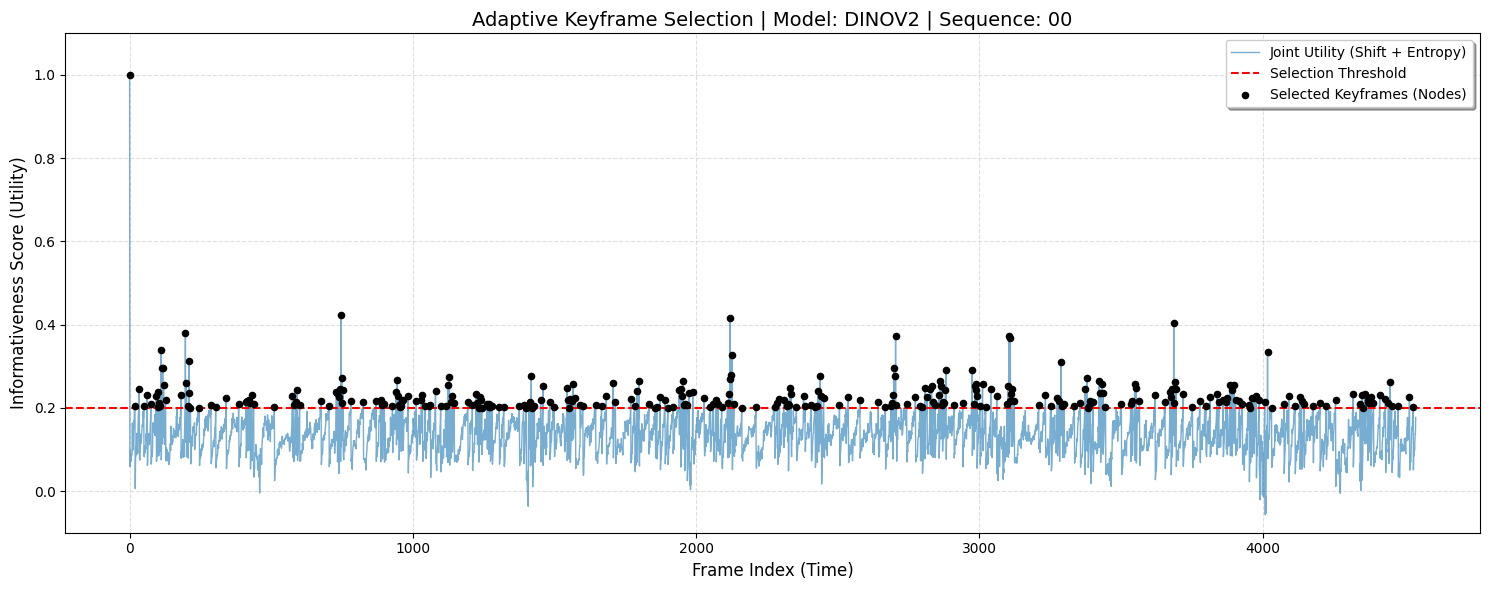

dinov2 - 01: 100%|██████████| 1101/1101 [00:40<00:00, 26.89it/s]


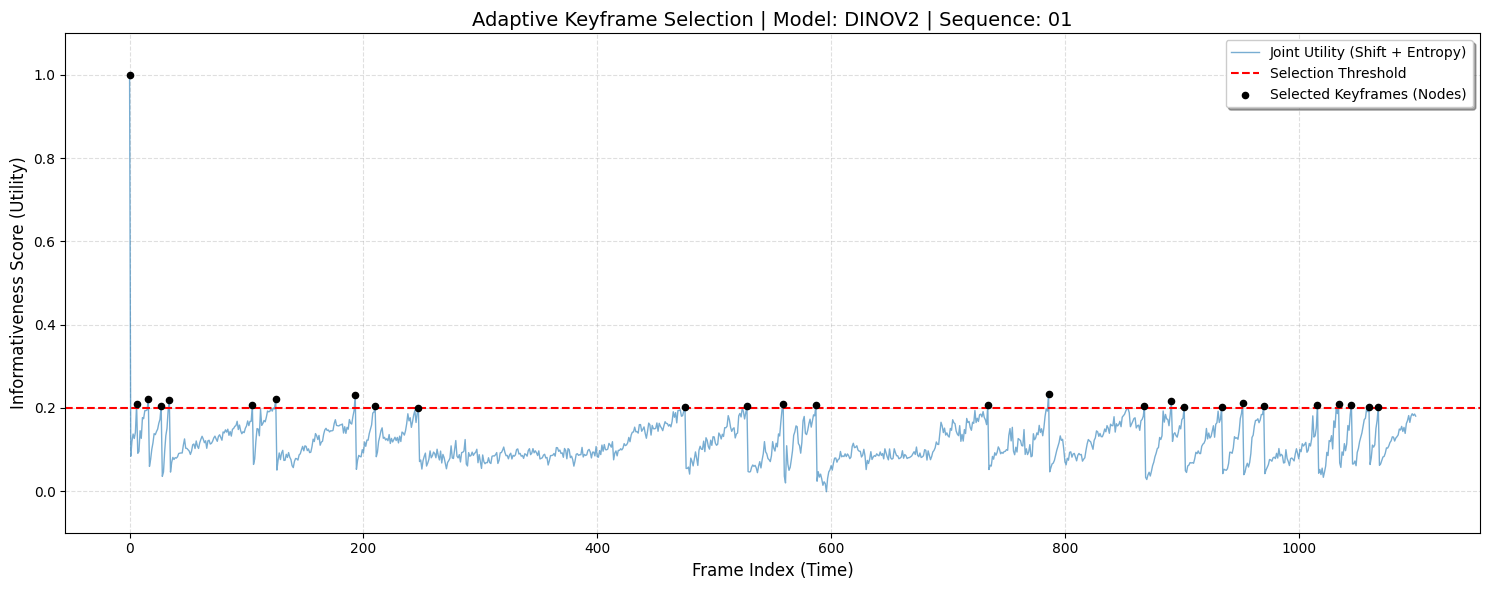

dinov2 - 05: 100%|██████████| 2761/2761 [01:42<00:00, 27.00it/s]


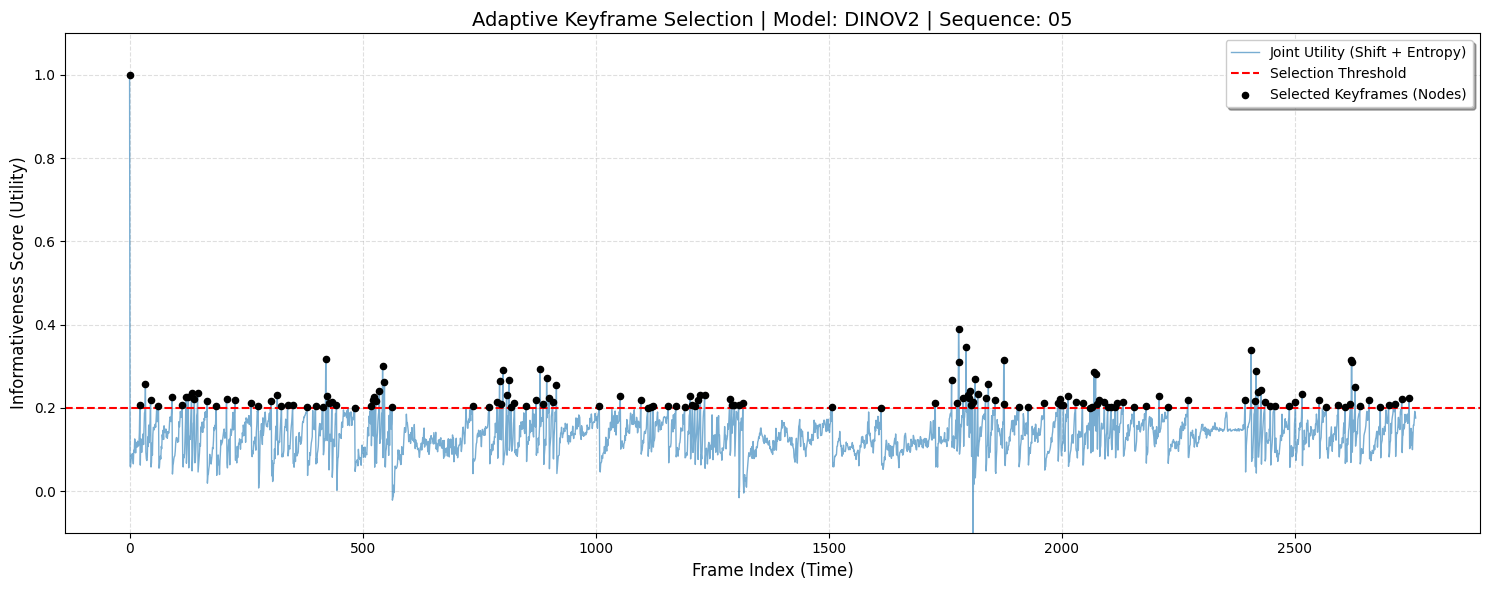

dinov2 - 06: 100%|██████████| 1101/1101 [00:40<00:00, 27.09it/s]


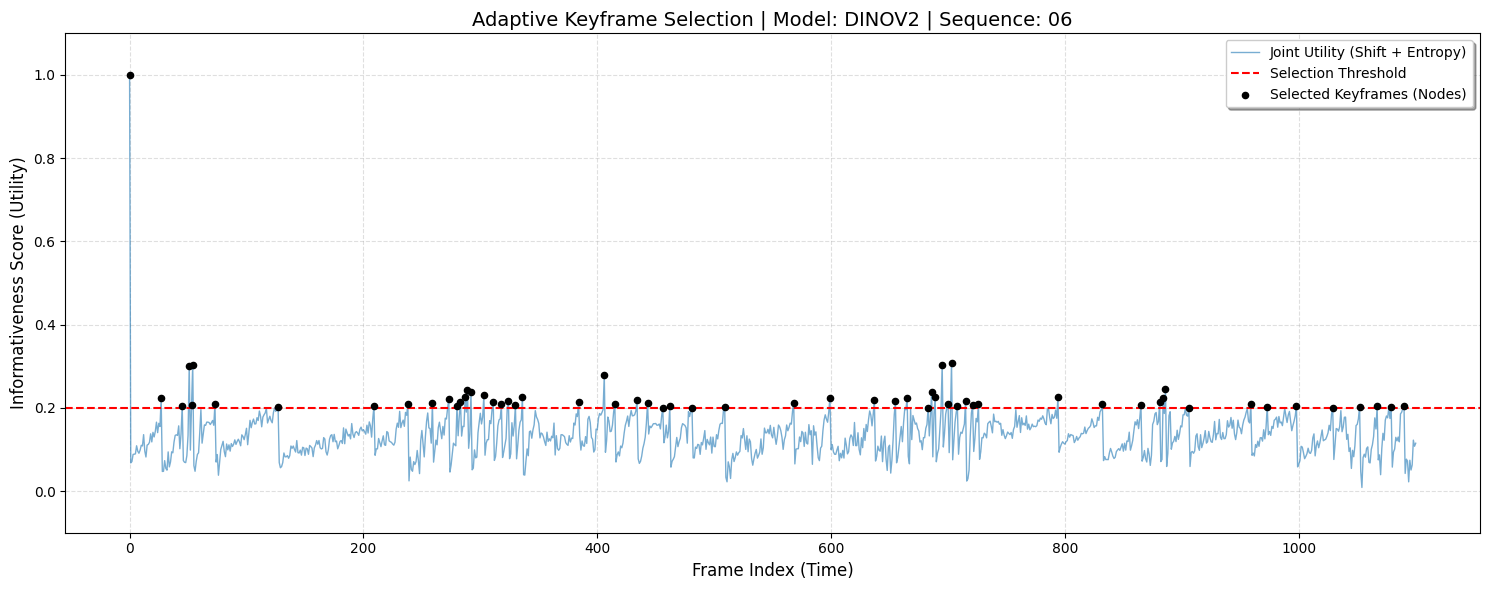


>>> Initializing CLIP...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
clip - 00: 100%|██████████| 4541/4541 [02:29<00:00, 30.31it/s]


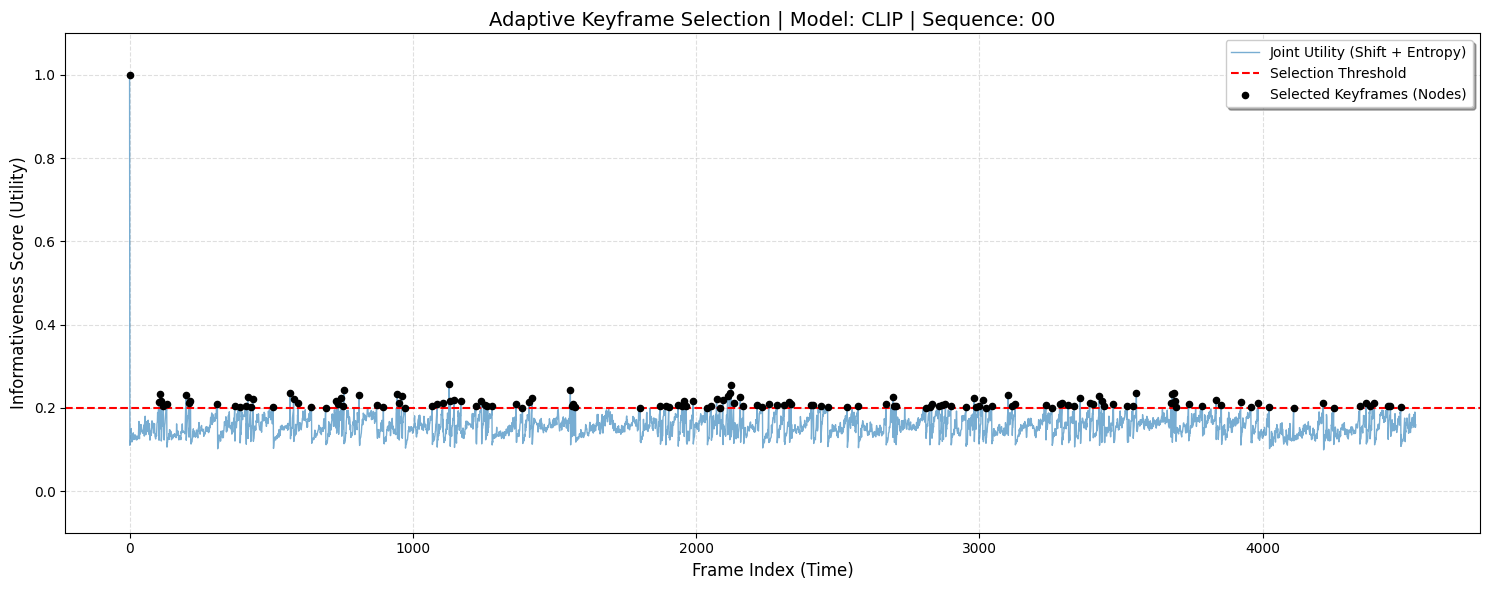

clip - 01: 100%|██████████| 1101/1101 [00:36<00:00, 30.47it/s]


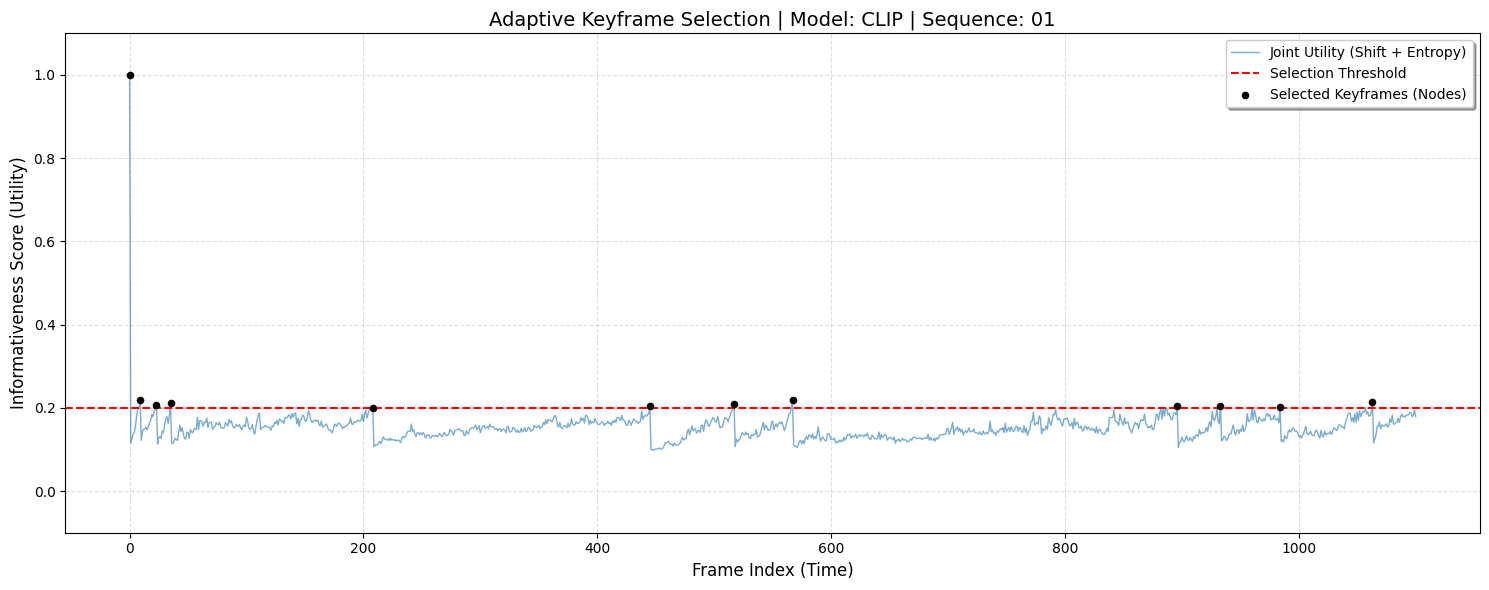

clip - 05: 100%|██████████| 2761/2761 [01:29<00:00, 30.87it/s]


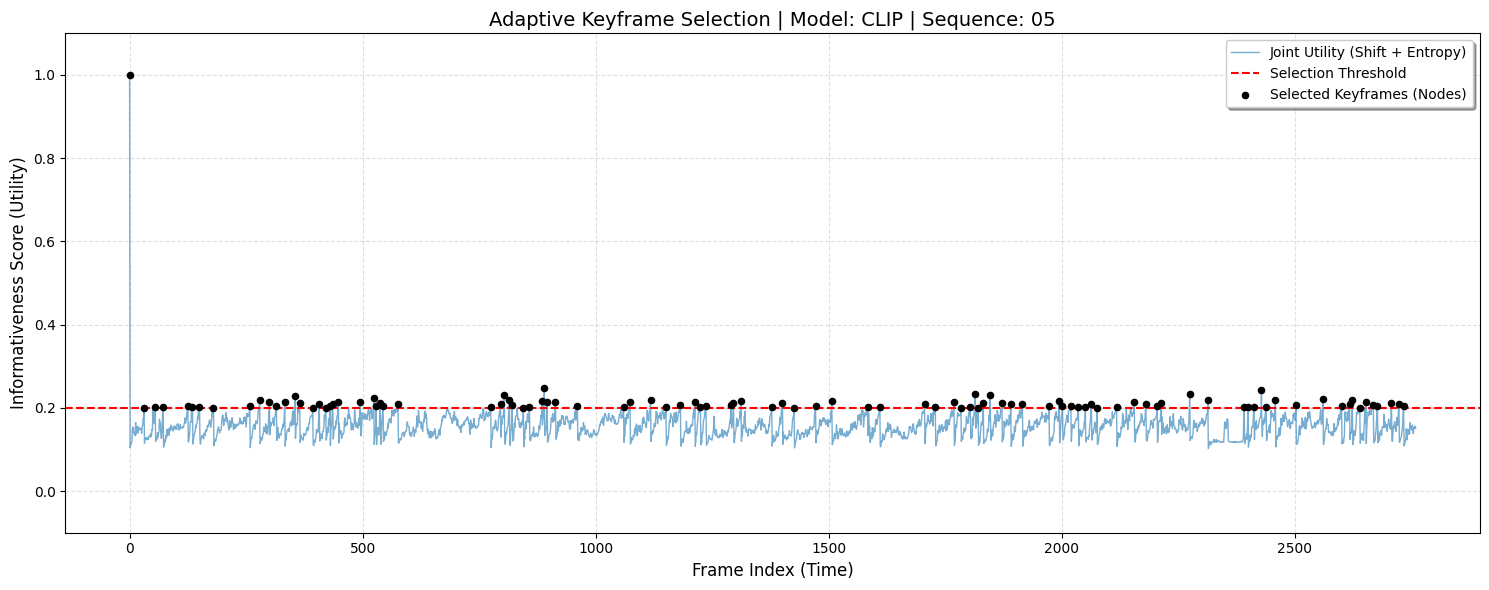

clip - 06: 100%|██████████| 1101/1101 [00:35<00:00, 31.06it/s]


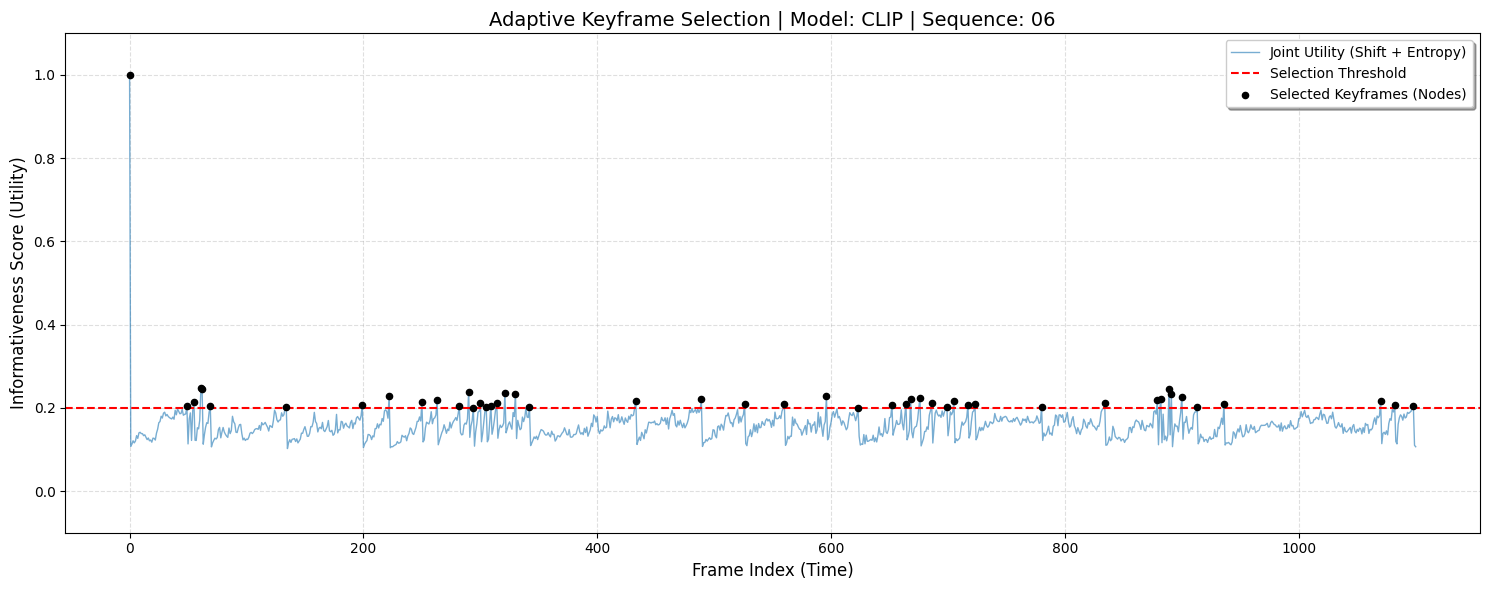


>>> Initializing SIGLIP...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

siglip - 00: 100%|██████████| 4541/4541 [02:32<00:00, 29.69it/s]


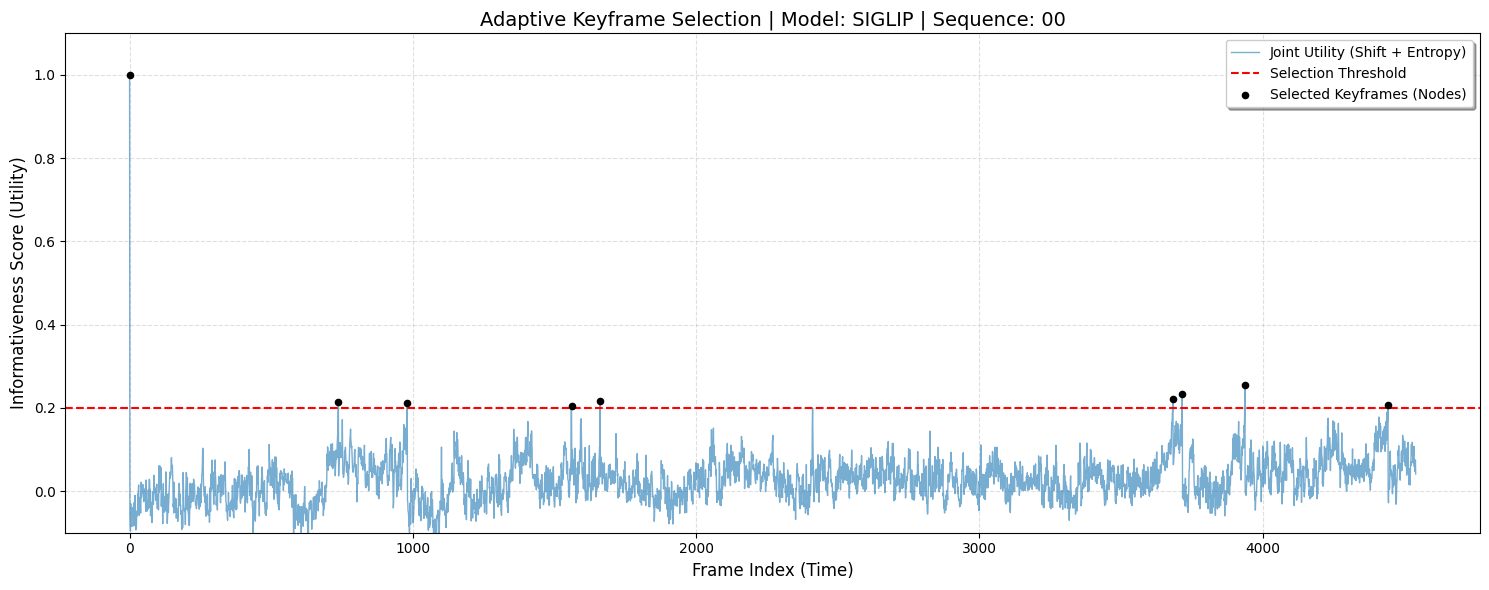

siglip - 01: 100%|██████████| 1101/1101 [00:37<00:00, 29.34it/s]


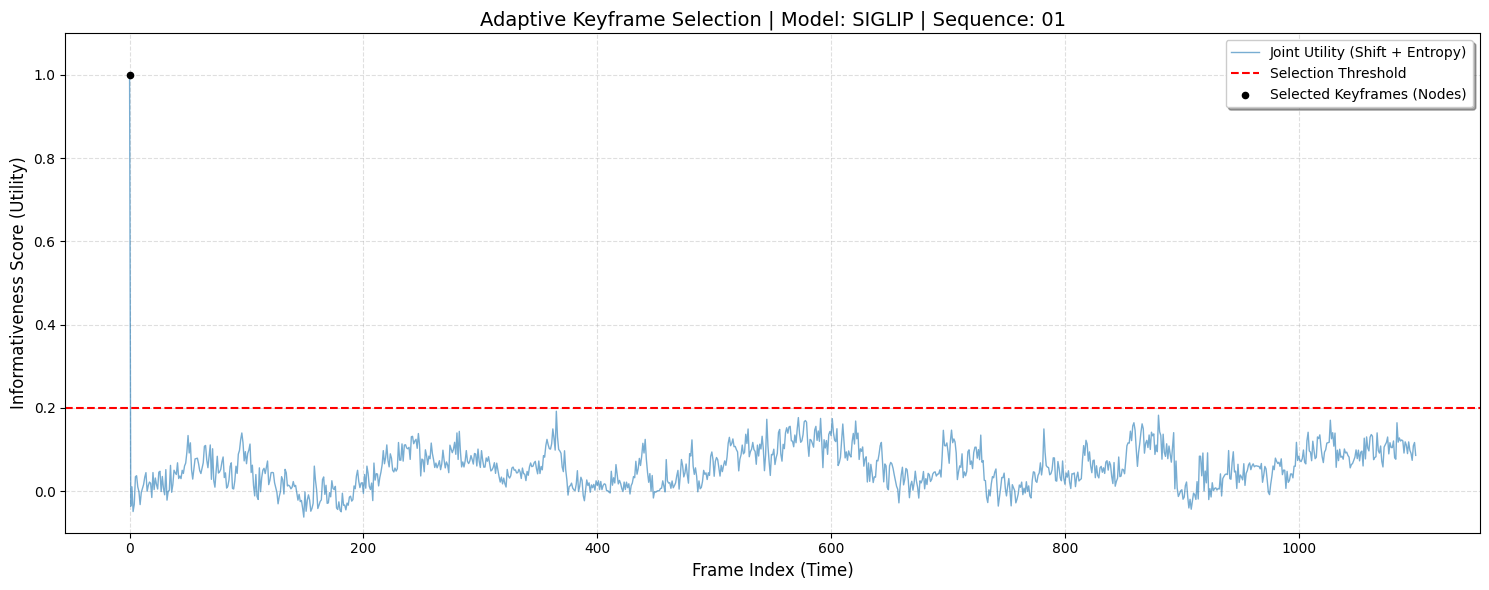

siglip - 05: 100%|██████████| 2761/2761 [01:32<00:00, 29.73it/s]


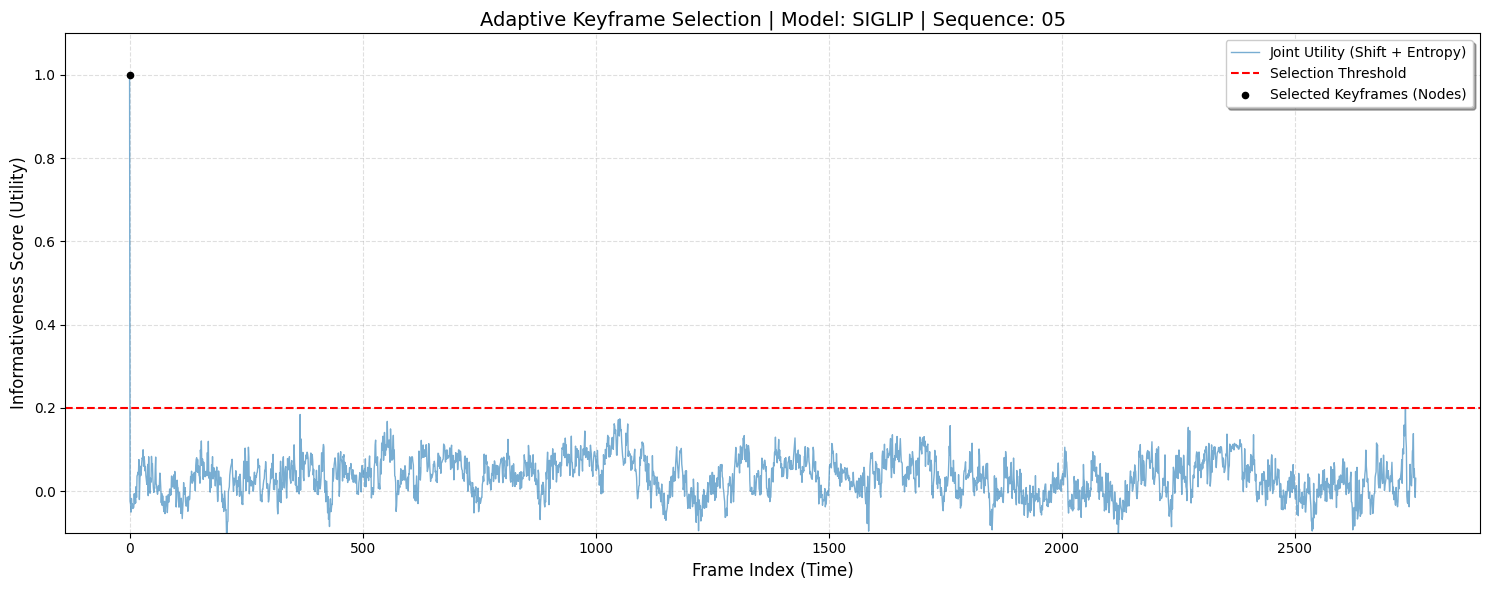

siglip - 06: 100%|██████████| 1101/1101 [00:36<00:00, 29.87it/s]


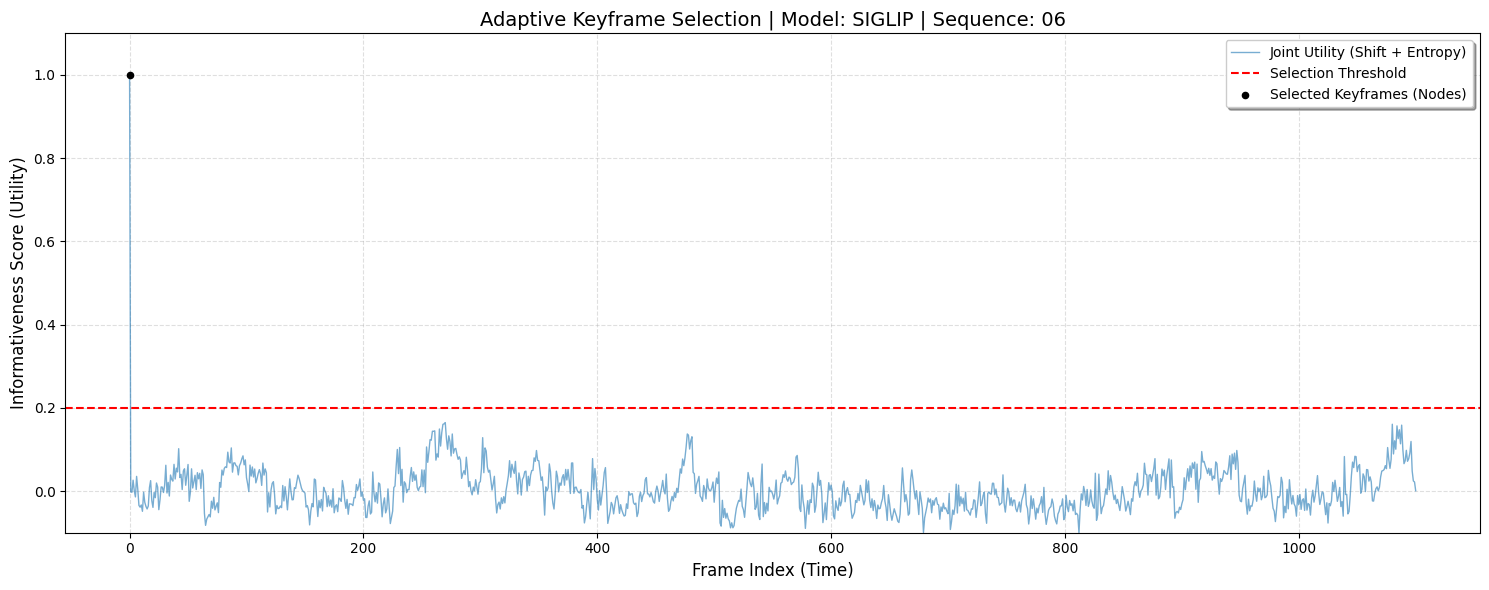

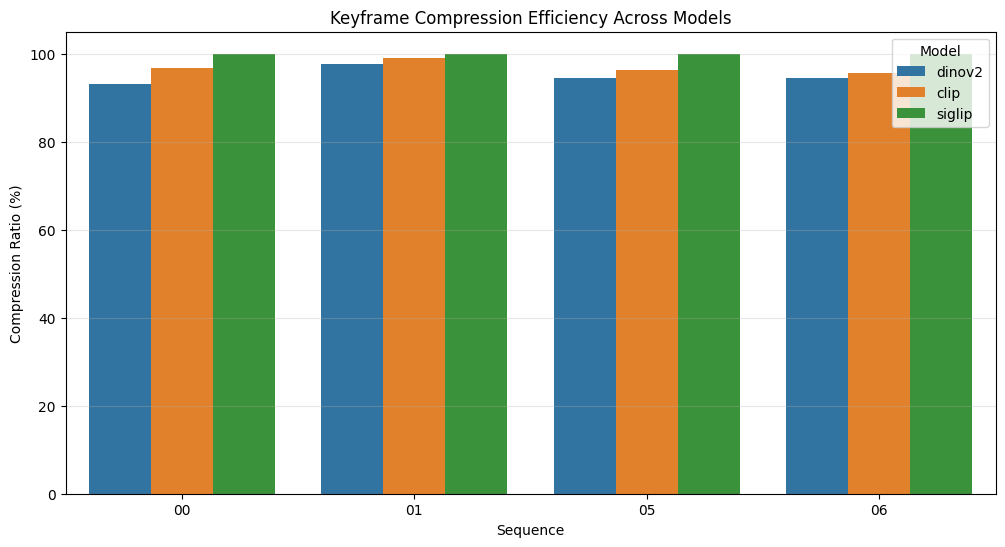

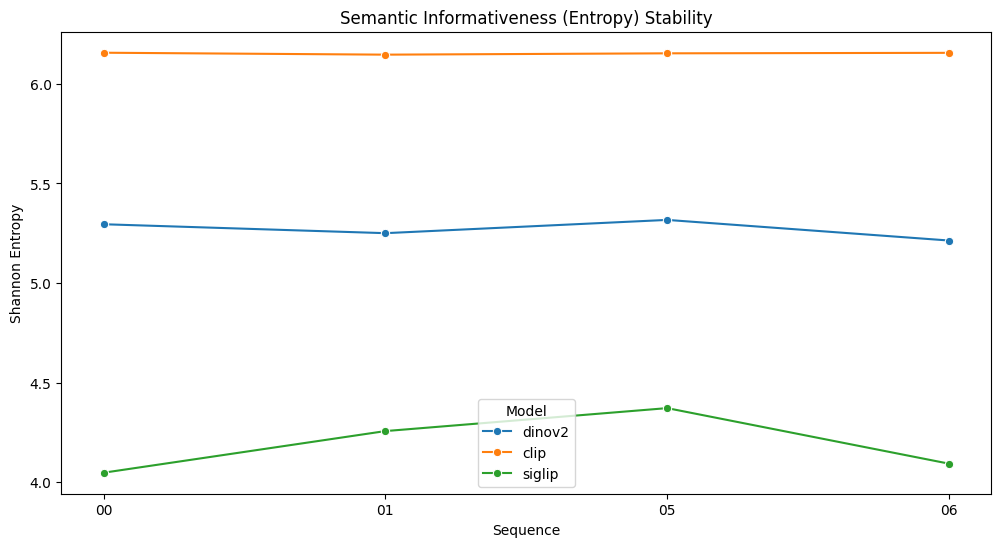

Pipeline Complete. All graphs generated.


In [16]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from transformers import (AutoImageProcessor, AutoModel, 
                          CLIPProcessor, CLIPModel, 
                          SiglipProcessor, SiglipModel)
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    BASE_DIR = "/kaggle/input/kitti-dataset/Dataset"
    SEQUENCES = ["00", "01", "05", "06"] 
    MODELS_TO_TEST = ["dinov2", "clip", "siglip"]
    MODEL_MAP = {
        "dinov2": "facebook/dinov2-base",
        "clip": "openai/clip-vit-base-patch32",
        "siglip": "google/siglip-base-patch16-224"
    }
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    UTILITY_THRESHOLD = 0.20
    ALPHA, BETA = 0.75, 0.25

# ==========================================
# 2. EXTRACTOR (FIXED FOR ALL MODELS)
# ==========================================
class UniversalExtractor:
    def __init__(self, mode):
        self.mode = mode
        m_id = Config.MODEL_MAP[mode]
        print(f"\n>>> Initializing {mode.upper()}...")
        
        if mode == "dinov2":
            self.proc = AutoImageProcessor.from_pretrained(m_id)
            self.model = AutoModel.from_pretrained(m_id).to(Config.DEVICE)
        elif mode == "clip":
            self.proc = CLIPProcessor.from_pretrained(m_id)
            self.model = CLIPModel.from_pretrained(m_id).to(Config.DEVICE)
        elif mode == "siglip":
            self.proc = SiglipProcessor.from_pretrained(m_id)
            self.model = SiglipModel.from_pretrained(m_id).to(Config.DEVICE)
        self.model.eval()

    def get_features(self, image_path):
        img = Image.open(image_path).convert("RGB")
        inputs = self.proc(images=img, return_tensors="pt").to(Config.DEVICE)
        
        with torch.no_grad():
            if self.mode == "dinov2":
                out = self.model(**inputs)
                # DINOv2: Use the [CLS] token from the last hidden state
                emb = out.last_hidden_state[:, 0, :]
            else:
                # CLIP & SigLIP: Use the specialized image feature method
                # This returns a raw tensor directly
                emb = self.model.get_image_features(**inputs)
            
            # --- ROBUST TENSOR EXTRACTION ---
            # If for some reason it's still a wrapper, pull the tensor out
            if hasattr(emb, 'pooler_output'):
                emb = emb.pooler_output
            elif isinstance(emb, (list, tuple)):
                emb = emb[0]
            
            # Now safely perform math for Step 01 Metrics
            emb_tensor = emb.detach() 
            probs = F.softmax(emb_tensor, dim=-1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-9)).item()
            
            return emb_tensor.cpu().numpy(), entropy

# ==========================================
# 3. PLOTTING FUNCTIONS
# ==========================================
def save_individual_plots(df, seq, model_name):
    plt.figure(figsize=(15, 6))
    
    # 1. Plot the continuous Utility Score (Shift + Entropy)
    plt.plot(df['frame'], df['utility'], color='#1f77b4', 
             label='Joint Utility (Shift + Entropy)', alpha=0.6, linewidth=1)
    
    # 2. Plot the Selection Threshold
    plt.axhline(y=Config.UTILITY_THRESHOLD, color='red', 
                linestyle='--', label='Selection Threshold', linewidth=1.5)
    
    # 3. Filter for frames where is_kf is True and plot dots
    keyframes_only = df[df['is_kf'] == True]
    if not keyframes_only.empty:
        plt.scatter(keyframes_only['frame'], keyframes_only['utility'], 
                    color='black', s=20, zorder=5, label='Selected Keyframes (Nodes)')
    
    # Formatting for Thesis / Article 1
    plt.title(f"Adaptive Keyframe Selection | Model: {model_name.upper()} | Sequence: {seq}", fontsize=14)
    plt.xlabel("Frame Index (Time)", fontsize=12)
    plt.ylabel("Informativeness Score (Utility)", fontsize=12)
    
    # CRITICAL: Show the legend
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    
    # Set y-axis limits for better visibility (Utility usually sits 0-1.0)
    plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.savefig(f"plot_utility_{model_name}_seq{seq}.png", dpi=300)
    plt.show() # Shows in Kaggle/Jupyter cell
    plt.close()

def generate_master_visuals(master_df):
    # Data Cleaning: Convert "93.04%" -> 93.04
    master_df['Comp_Numeric'] = master_df['Compression_Ratio'].str.replace('%', '').astype(float)
    master_df['Avg_Inf_Numeric'] = master_df['Avg_Informativeness'].astype(float)

    # Graph 1: Compression Comparison
    plt.figure(figsize=(12, 6))
    sns.barplot(data=master_df, x='Sequence', y='Comp_Numeric', hue='Model')
    plt.title("Keyframe Compression Efficiency Across Models")
    plt.ylabel("Compression Ratio (%)")
    plt.grid(axis='y', alpha=0.3)
    plt.savefig("cross_model_compression.png")
    plt.show()

    # Graph 2: Informativeness Stability
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=master_df, x='Sequence', y='Avg_Inf_Numeric', hue='Model', marker='o')
    plt.title("Semantic Informativeness (Entropy) Stability")
    plt.ylabel("Shannon Entropy")
    plt.savefig("cross_model_entropy.png")
    plt.show()

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    results_summary = []

    for model_name in Config.MODELS_TO_TEST:
        extractor = UniversalExtractor(model_name)
        
        for seq in Config.SEQUENCES:
            img_dir = os.path.join(Config.BASE_DIR, "sequences", seq, "image_2")
            images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))])
            
            kf_indices, last_emb, logs = [], None, []
            
            for i, name in enumerate(tqdm(images, desc=f"{model_name} - {seq}")):
                emb, ent = extractor.get_features(os.path.join(img_dir, name))
                if i == 0:
                    utility, shift, is_kf = 1.0, 1.0, True
                else:
                    shift = 1 - cosine_similarity(emb, last_emb)[0][0]
                    norm_ent = (ent - 5.0) / 3.0
                    utility = (Config.ALPHA * shift) + (Config.BETA * norm_ent)
                    is_kf = utility > Config.UTILITY_THRESHOLD
                
                if is_kf:
                    kf_indices.append(i)
                    last_emb = emb
                logs.append({'frame': i, 'utility': utility, 'entropy': ent, 'is_kf': is_kf})
            
            # Save metrics and individual plots
            df_seq = pd.DataFrame(logs)
            save_individual_plots(df_seq, seq, model_name)
            
            comp = (1 - len(kf_indices)/len(images)) * 100
            results_summary.append({
                'Model': model_name, 'Sequence': seq, 
                'Total_Frames': len(images), 'Keyframes': len(kf_indices),
                'Compression_Ratio': f"{comp:.2f}%", 
                'Avg_Informativeness': np.mean(df_seq['entropy'])
            })

    # Generate Final Article Tables and Master Visuals
    master_df = pd.DataFrame(results_summary)
    master_df.to_csv("article1_master_benchmark.csv", index=False)
    generate_master_visuals(master_df)
    print("Pipeline Complete. All graphs generated.")